In [1]:
import pandas as pd
import importlib
import sys
import os
sys.path.append(os.path.abspath('..'))

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
import Estrategia
importlib.reload(Estrategia)
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel
EstrategiaMLEquiponderada = Estrategia.EstrategiaMLEquiponderada
EstrategiaMLMinVarAlphaTilt = Estrategia.EstrategiaMLMinVarAlphaTilt
EstrategiaMLMonteCarlo = Estrategia.EstrategiaMLMonteCarlo
EstrategiaMLEquiponderadaMacro = Estrategia.EstrategiaMLEquiponderadaMacro

# EURO STOXX 50

In [2]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers}")

# tickers = [
#     "ADS.DE",    # Adidas
#     "ADYEN.AS",  # Adyen
#     "AD.AS",     # Ahold Delhaize
#     "AI.PA",     # Air Liquide
#     "AIR.PA",    # Airbus
#     "ALV.DE",    # Allianz
#     "ABI.BR",    # Anheuser-Busch InBev
#     "ASML.AS",   # ASML
#     "CS.PA",     # AXA
#     "BBVA.MC",   # BBVA
#     "SAN.MC",    # Santander
#     "BAS.DE",    # BASF
#     "BAYN.DE",   # Bayer
#     "BMW.DE",    # BMW
#     "BNP.PA",    # BNP Paribas
#     "CRH.L",     # CRH
#     "MBG.DE",    # Mercedes-Benz
#     "BN.PA",     # Danone
#     "DB1.DE",    # Deutsche Börse
#     "DHL.DE",    # Deutsche Post
#     "DTE.DE",    # Deutsche Telekom
#     "ENEL.MI",   # Enel
#     "ENI.MI",    # ENI
#     "EL.PA",     # EssilorLuxottica
#     "FLTR.L",    # Flutter Entertainment
#     "RMS.PA",    # Hermès
#     "IBE.MC",    # Iberdrola
#     "ITX.MC",    # Inditex
#     "IFX.DE",    # Infineon
#     "INGA.AS",   # ING Groep
#     "ISP.MI",    # Intesa Sanpaolo
#     "KER.PA",    # Kering
#     "KNEBV.HE",  # Kone
#     "OR.PA",     # L'Oréal
#     "LIN.DE",    # Linde
#     "MC.PA",     # LVMH
#     "MUV2.DE",   # Münchener Rück
#     "RI.PA",     # Pernod Ricard
#     "PHIA.AS",   # Philips
#     "PRX.AS",    # Prosus
#     "SAF.PA",    # Safran
#     "SAN.PA",    # Sanofi
#     "SAP.DE",    # SAP
#     "SU.PA",     # Schneider Electric
#     "SIE.DE",    # Siemens
#     "STLAM.MI",  # Stellantis (no STLA.MI)
#     "TTE.PA",    # TotalEnergies
#     "DG.PA",     # Vinci
#     "VOW3.DE",   # Volkswagen Pref
#     "VNA.DE",    # Vonovia
# ]

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA', 'ALV.DE', 'ABI.BR', 'ARGX.BR', 'ASML.AS', 'CS.PA', 'BAS.DE', 'BAYN.DE', 'BBVA.MC', 'SAN.MC', 'BMW.DE', 'BNP.PA', 'BN.PA', 'DBK.DE', 'DB1.DE', 'DHL.DE', 'DTE.DE', 'ENEL.MI', 'ENI.MI', 'EL.PA', 'RACE.MI', 'RMS.PA', 'IBE.MC', 'ITX.MC', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'OR.PA', 'MC.PA', 'MBG.DE', 'MUV2.DE', 'NDA-FI.HE', 'PRX.AS', 'RHM.DE', 'SAF.PA', 'SGO.PA', 'SAN.PA', 'SAP.DE', 'SU.PA', 'SIE.DE', 'ENR.DE', 'TTE.PA', 'DG.PA', 'UCG.MI', 'VOW.DE', 'WKL.AS']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_38524\4012662861.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


## RandomForest + EstrategiaMLMonteCarlo

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2017-01-06 → 2022-12-30 | AUC=0.5469 | {'class_weight': {0: 1, 1: 3}, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 0.01, 'n_estimators': 250}
2023-01-06 | VP=10000000 | pesos={'ADS.DE': 0.050067621452094084, 'ADYEN.AS': 0.03592801176365353, 'ASML.AS': 0.026021317907897194, 'BBVA.MC': 0.024719147666306406, 'DBK.DE': 0.04536551432036623, 'DHL.DE': 0.030625401977664193, 'EL.PA': 0.07804692076021054, 'ENI.MI': 0.023129517202115417, 'IFX.DE': 0.10000131314365535, 'MC.PA': 0.07730976545128544, 'MUV2.DE': 0.14792066621754327, 'RHM.DE': 0.023702580059480595, 'RMS.PA': 0.14079408491032036, 'UCG.MI': 0.17018006515425724, 'VOW.DE': 0.02618807201315016}
2023-01-13 | VP=10211571 | pesos={'ADS.DE': 0.026187411106735246, 'ADYEN.AS': 0.03753482504736971, 'ASML.AS': 0.04700003241534442, 'BBVA.MC': 0.07748231643840332, 'DBK.DE': 0.025663089783019562, 'DHL.DE': 0.03745373719239409, 'IFX.DE': 0.045390617551435405, 'INGA.AS': 0.10844898613884588, 'MC.PA': 0.03083622197355644, 'MUV2.D

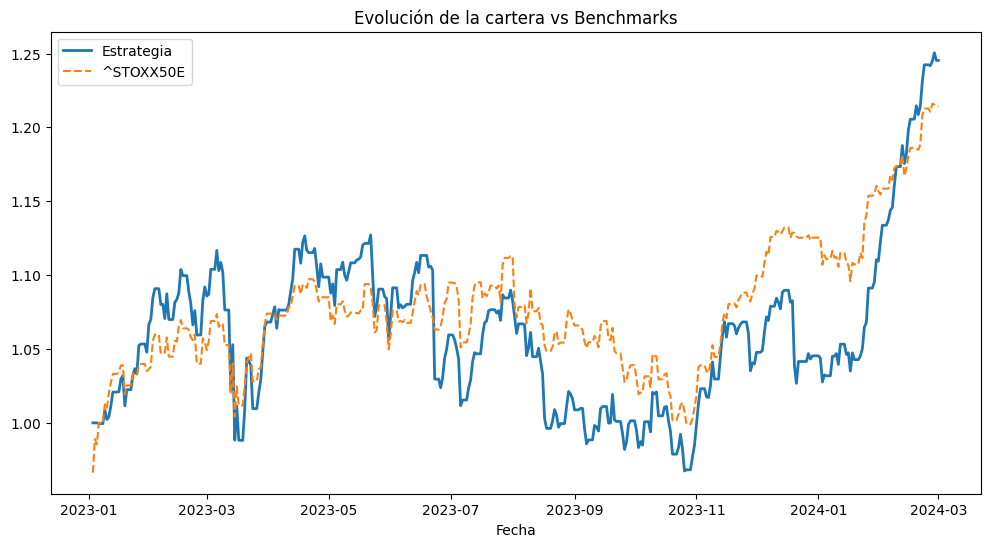

,Estrategia,^STOXX50E
Rentabilidad total,24.53%,25.64%
Rentabilidad anualizada,13.96%,14.57%
Volatilidad anualizada,16.34%,11.51%
Sharpe,0.88,1.24
Sortino,1.15,1.78
Max Drawdown,-14.17%,-10.22%
Calmar,0.99,1.43
Win rate,41.37%,38.53%
Mejor periodo,3.36%,2.36%
Peor periodo,-6.69%,-3.46%


In [ ]:
start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.12)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLEquiponderada

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2017-01-06 → 2022-12-30 | AUC=0.5469 | {'class_weight': {0: 1, 1: 3}, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 0.01, 'n_estimators': 250}
2023-01-06 | VP=10000000 | pesos={'ADS.DE': 0.06666666666666667, 'RHM.DE': 0.06666666666666667, 'RMS.PA': 0.06666666666666667, 'ADYEN.AS': 0.06666666666666667, 'ASML.AS': 0.06666666666666667, 'UCG.MI': 0.06666666666666667, 'IFX.DE': 0.06666666666666667, 'MC.PA': 0.06666666666666667, 'VOW.DE': 0.06666666666666667, 'BBVA.MC': 0.06666666666666667, 'DHL.DE': 0.06666666666666667, 'ENI.MI': 0.06666666666666667, 'MUV2.DE': 0.06666666666666667, 'EL.PA': 0.06666666666666667, 'DBK.DE': 0.06666666666666667}
2023-01-13 | VP=10267996 | pesos={'BBVA.MC': 0.06666666666666667, 'IFX.DE': 0.06666666666666667, 'ASML.AS': 0.06666666666666667, 'MUV2.DE': 0.06666666666666667, 'RHM.DE': 0.06666666666666667, 'UCG.MI': 0.06666666666666667, 'ADS.DE': 0.06666666666666667, 'DBK.DE': 0.06666666666666667, 'RMS.PA': 0.06666666666666667, 'ADYEN.AS': 0.066

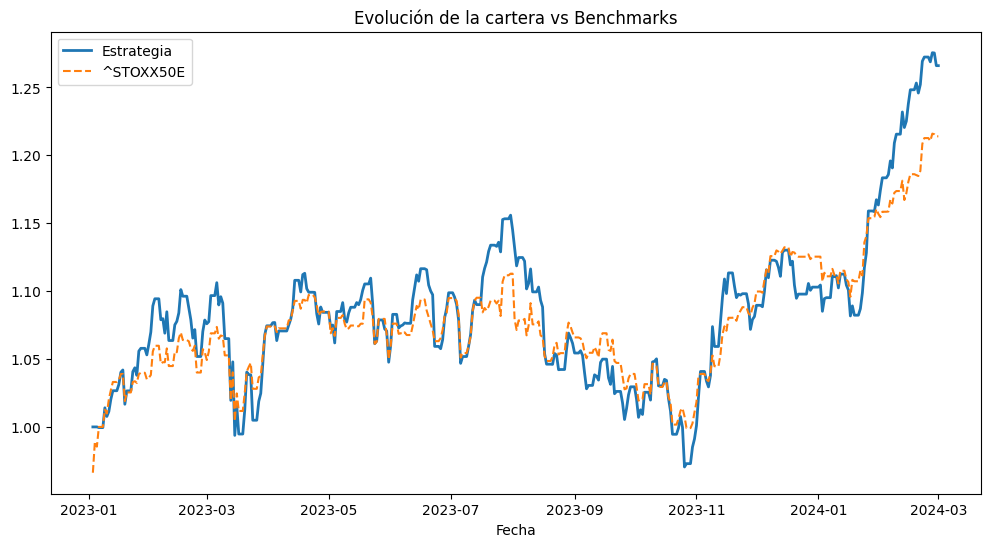

,Estrategia,^STOXX50E
Rentabilidad total,26.61%,25.64%
Rentabilidad anualizada,15.09%,14.57%
Volatilidad anualizada,15.77%,11.51%
Sharpe,0.97,1.24
Sortino,1.35,1.78
Max Drawdown,-16.04%,-10.22%
Calmar,0.94,1.43
Win rate,39.48%,38.53%
Mejor periodo,3.47%,2.36%
Peor periodo,-5.17%,-3.46%


In [4]:
import warnings
warnings.filterwarnings("ignore", category=ResourceWarning)

start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=15, umbral_salida=22)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLEquiponderada

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2014-01-03 → 2019-12-27 | AUC=0.5500 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2020-01-03 | VP=10000000 | pesos={'NOKIA.HE': 0.06666666666666667, 'IFX.DE': 0.06666666666666667, 'BNP.PA': 0.06666666666666667, 'ABI.BR': 0.06666666666666667, 'ASML.AS': 0.06666666666666667, 'SIE.DE': 0.06666666666666667, 'STLAM.MI': 0.06666666666666667, 'RMS.PA': 0.06666666666666667, 'DHL.DE': 0.06666666666666667, 'UCG.MI': 0.06666666666666667, 'SAF.PA': 0.06666666666666667, 'SAP.DE': 0.06666666666666667, 'SU.PA': 0.06666666666666667, 'SGO.PA': 0.06666666666666667, 'MC.PA': 0.06666666666666667}
2020-01-10 | VP=10063205 | pesos={'UCG.MI': 0.06666666666666667, 'MC.PA': 0.06666666666666667, 'ABI.BR': 0.06666666666666667, 'SAP.DE': 0.06666666666666667, 'SAF.PA': 0.06666666666666667, 'SIE.DE': 0.06666666666666667, 'SGO.PA': 0.06666666666666667, 'NOKIA.HE': 0.06666666666666667, 'STLAM.MI': 0.06666666666666667, 'DHL.DE'

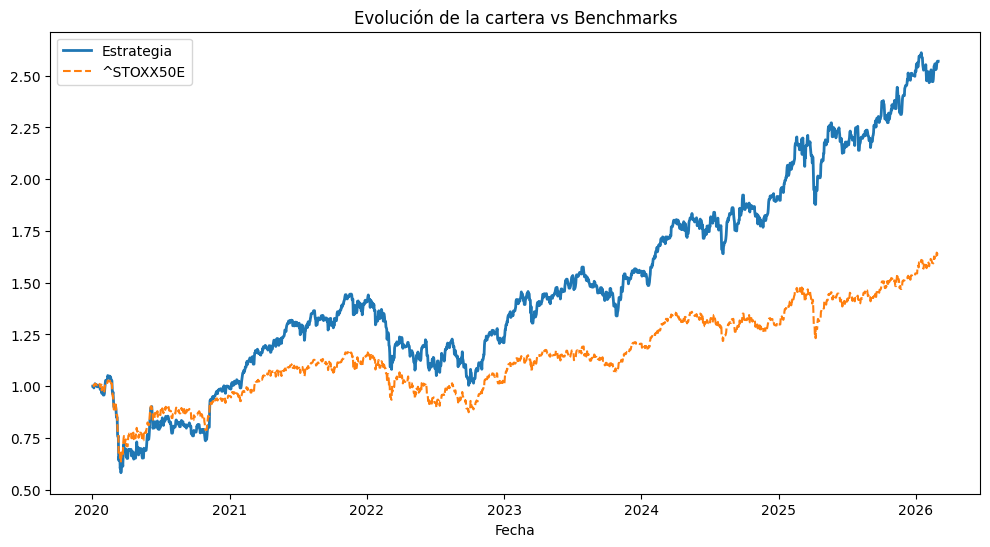

,Estrategia,^STOXX50E
Rentabilidad total,156.99%,62.68%
Rentabilidad anualizada,11.16%,5.60%
Volatilidad anualizada,20.83%,16.78%
Sharpe,0.61,0.41
Sortino,0.86,0.56
Max Drawdown,-44.67%,-38.27%
Calmar,0.25,0.15
Win rate,38.64%,36.77%
Mejor periodo,11.44%,9.24%
Peor periodo,-15.34%,-12.40%


In [24]:
start_date = "2020-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=4)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=15, umbral_salida=22)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLMonteCarlo

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2014-01-03 → 2019-12-27 | AUC=0.5437 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2020-01-03 | VP=10000000 | pesos={'ABI.BR': 0.023599027342351784, 'ADS.DE': 0.15217668690003294, 'ASML.AS': 0.15217668690003294, 'BN.PA': 0.03290357253217159, 'BNP.PA': 0.029426223395531265, 'DHL.DE': 0.06989514775646363, 'IFX.DE': 0.03556020115282773, 'MC.PA': 0.14347745286375863, 'NOKIA.HE': 0.020477591150132177, 'RMS.PA': 0.05229576446485309, 'SAF.PA': 0.027444596309503085, 'SAP.DE': 0.038769817769584124, 'SIE.DE': 0.15217668690003294, 'STLAM.MI': 0.021992849624472108, 'UCG.MI': 0.04762769493825203}
2020-01-10 | VP=10138868 | pesos={'ABI.BR': 0.022207552064781547, 'BNP.PA': 0.06145110563907644, 'DHL.DE': 0.07567378309213167, 'MBG.DE': 0.02708858122032231, 'MC.PA': 0.15566779523158886, 'NOKIA.HE': 0.02419215309528192, 'RMS.PA': 0.0502583149897987, 'SAF.PA': 0.10151158001386298, 'SAP.DE': 0.023558196096634013, 'SG

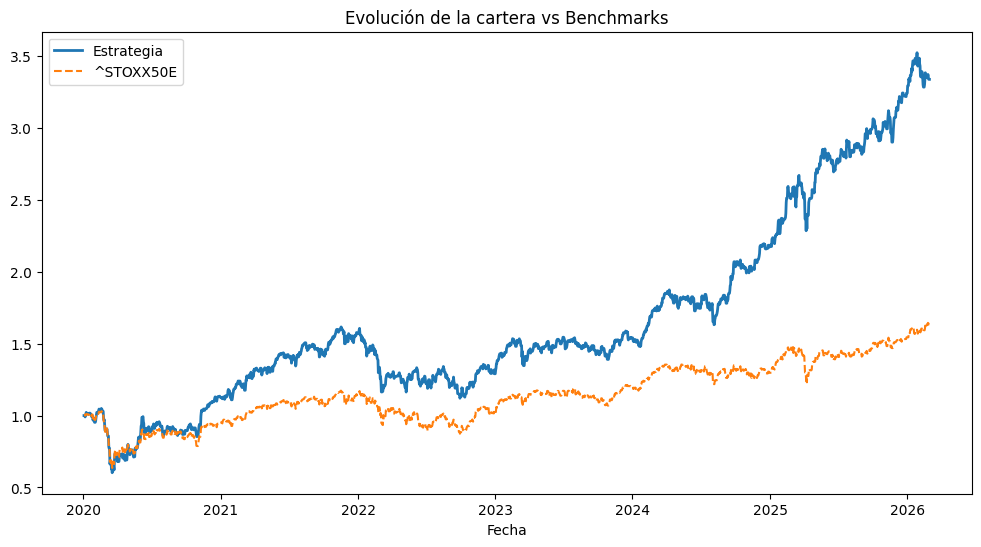

,Estrategia,^STOXX50E
Rentabilidad total,233.97%,62.68%
Rentabilidad anualizada,14.47%,5.60%
Volatilidad anualizada,20.36%,16.78%
Sharpe,0.77,0.41
Sortino,1.07,0.56
Max Drawdown,-42.49%,-38.27%
Calmar,0.34,0.15
Win rate,39.04%,36.77%
Mejor periodo,10.77%,9.24%
Peor periodo,-14.04%,-12.40%


In [25]:
start_date = "2020-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLEquiponderadaMacro

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2014-01-03 → 2019-12-27 | AUC=0.5430 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 1.0}
2020-01-03 | VP=10000000 | pesos={'NOKIA.HE': 0.06666666666666667, 'IFX.DE': 0.06666666666666667, 'BNP.PA': 0.06666666666666667, 'ABI.BR': 0.06666666666666667, 'SIE.DE': 0.06666666666666667, 'STLAM.MI': 0.06666666666666667, 'RHM.DE': 0.06666666666666667, 'ASML.AS': 0.06666666666666667, 'SAF.PA': 0.06666666666666667, 'SAP.DE': 0.06666666666666667, 'VOW.DE': 0.06666666666666667, 'ISP.MI': 0.06666666666666667, 'VOW3.DE': 0.06666666666666667, 'DHL.DE': 0.06666666666666667, 'SGO.PA': 0.06666666666666667}
2020-01-10 | VP=10111826 | pesos={'DHL.DE': 0.06666666666666667, 'ASML.AS': 0.06666666666666667, 'RHM.DE': 0.06666666666666667, 'BNP.PA': 0.06666666666666667, 'VOW.DE': 0.06666666666666667, 'SGO.PA': 0.06666666666666667, 'VOW3.DE': 0.06666666666666667, 'STLAM.MI': 0.06666666666666667, 'ABI.BR': 0.06666666666666667, 'SAF

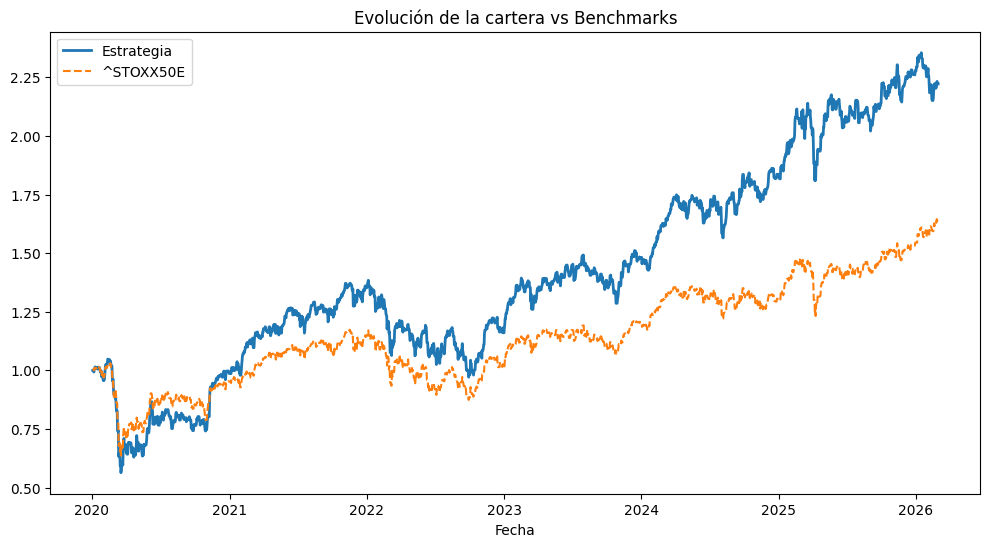

,Estrategia,^STOXX50E
Rentabilidad total,122.20%,62.68%
Rentabilidad anualizada,9.36%,5.60%
Volatilidad anualizada,20.79%,16.78%
Sharpe,0.53,0.41
Sortino,0.75,0.56
Max Drawdown,-46.24%,-38.27%
Calmar,0.20,0.15
Win rate,38.42%,36.77%
Mejor periodo,11.96%,9.24%
Peor periodo,-14.95%,-12.40%


In [7]:
start_date = "2020-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"../eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLEquiponderadaMacro(
    modelo        = modelo,
    n_activos_obj = 15,
    umbral_salida = 22,
    ticker_indice = "^STOXX50E",
    umbral_vol    = 0.20,  # vol anualizada > 20% → reducir exposición
    exposicion_rv = 0.50   # reducir al 50%
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])